## Preprocess microglialess mouse brain Parse scRNA-seq

This script loads the results of `alevin fry` (see `alevin_pipeline`) and formats into two different anndata objects: 
1) random hexamer and polydT primed "half cells" are kept separate. 
2) Counts from both are added (t2g_permit_known_combined.h5ad). 

In [ ]:
from pathlib import Path
import os
import sys

REPO_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "tealeaf").is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)


In [1]:
import pandas as pd
import collections

import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import scipy.sparse as sp
import scipy.io
import re
import scanpy as sc 

import seaborn as sns
import plotnine as p9
p9.theme_set(p9.theme_bw)

def sparse_sum(x, dim):
    return np.squeeze(np.asarray(x.sum(dim)))

In [2]:
# load cell meta data and counts for each sub library
data_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice")
#salmon_dir = data_dir / "salmon_spliceu" / "out_permit_known" / "quant_t2t_dedup" 
salmon_dir = data_dir / "salmon_per_sublib"# / "out_permit_known" / "quant_spliceu_t2g"

cells_meta = {}
count_mat = {}

srrdirs = [ item for item in salmon_dir.iterdir() if item.is_dir() ]
for srrdir in srrdirs: 
    quant_dir = srrdir / "out_permit_known" / "quant_spliceu_t2g" 
    
    cells_meta[srrdir.name] = pd.read_csv(quant_dir / "featureDump.txt", sep = "\t")
    cells_meta[srrdir.name]["sublibrary"] = srrdir.name

    dat_dir = quant_dir / "alevin"
    cache_file = dat_dir / "quants_mat.npz"
    if cache_file.exists(): # read the counts matrix. cache in a binary format for faster loading. this take a while the first time. 
        count_mat[srrdir.name] = scipy.sparse.load_npz(cache_file)
    else: 
        count_mat[srrdir.name] = scipy.io.mmread(dat_dir / "quants_mat.mtx") # cells x genes
        scipy.sparse.save_npz(cache_file, count_mat[sublibdir.name])
    


In [3]:
sublib_keys = list( count_mat.keys())
sublib_keys

['CAGATC',
 'ACTTGA',
 'CTTGTA',
 'TAGCTT',
 'GATCAG',
 'AGTCAA',
 'GGCTAC',
 'AGTTCC']

In [4]:
cells_meta = pd.concat([cells_meta[g] for g in sublib_keys], axis=0)

# used to keep track of what the corresponding row in the count matrix is
cells_meta = cells_meta.reset_index(drop=True).reset_index(names = "og_index")


In [5]:
cells_meta.sublibrary.drop_duplicates() == sublib_keys # all true

0          True
148824     True
300616     True
497099     True
676356     True
812106     True
987485     True
1157613    True
Name: sublibrary, dtype: bool

In [6]:
count_mat_all = scipy.sparse.vstack([count_mat[g] for g in sublib_keys])
count_mat_all.shape

(1348481, 56953)

Text(0.5, 0, 'log10(deduped reads)')

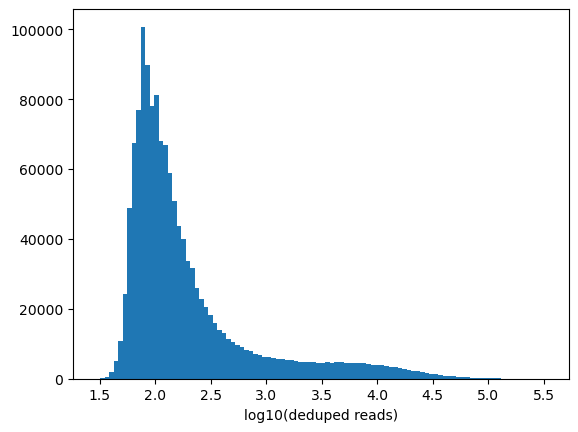

In [7]:
plt.hist(np.log10(cells_meta.DeduplicatedReads), 100)
plt.xlabel("log10(deduped reads)")

I think just the fat right tail are the real cells. 

## Load cell barcodes

For barcoding:  
Round 1 is RT: half (48) the wells are polyDT and half are random hexamer primed. It's not documented but the first 48 RT BCs are for polydT, the next 48 for ranhex, and that ordering gives the pairing. 

Rounds 2 and 3 are ligation. These use the same BC in both rounds. These are the union of the RT barcodes from Split-seq V1. 

The final 24mer BC is [rnd3 BC][rnd2 BC][rnd1 BC]. 

In [8]:
# get the Parse/V2 barcodes (thanks Scott!) 
parse_meta_dir = Path("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/Parse_meta")
ligation_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_ligation_barcodes.txt", sep = "\t", header = None)
ligation_BCs_v2 = ligation_BCs_v2[0].tolist() 
ligation_BCs_v2[:5]

['AACGTGAT', 'AAACATCG', 'ATGCCTAA', 'AGTGGTCA', 'ACCACTGT']

In [9]:
rt_BCs_v2 = pd.read_csv(parse_meta_dir / "Parse_RT_barcodes.txt", sep = "\t", header = None)
rt_BCs_v2 = rt_BCs_v2[0].tolist() 
len(rt_BCs_v2) # 96 barcodes (the order matters!)

96

In [10]:
# it was just a guess that this ordering is correct but it seems to be
polydT_hex_pairs_v2 = pd.DataFrame({"rnd1_BC" : rt_BCs_v2, "rnd1_well" : np.tile(np.arange(48), 2), "polydT" : [True] * 48 + [False] * 48}) 
ligation_BC_v2_dict = dict(zip(ligation_BCs_v2, np.arange(96)))

In [11]:
# extract the individual parts of the cell barcode
cells_meta["rnd3_BC"] = cells_meta.CB.str[:8]
cells_meta["rnd2_BC"] = cells_meta.CB.str[8:16]
cells_meta["rnd1_BC"] = cells_meta.CB.str[16:]

# convert to well IDs
cells_meta["rnd2_well"] = cells_meta["rnd2_BC"].map(ligation_BC_v2_dict)
cells_meta["rnd3_well"] = cells_meta["rnd3_BC"].map(ligation_BC_v2_dict)

cells_meta = pd.merge(cells_meta, polydT_hex_pairs_v2, on = "rnd1_BC", how = "left")

## Load gene names

In [12]:
genes = [ g.strip() for g in open(dat_dir / "quants_mat_cols.txt","r").readlines() ]
genes[:5] # these are transcripts if using t2t

mouse_genes = pd.read_csv("ensembl_mouse_genes.txt.gz", sep = "\t")
mouse_genes = mouse_genes[ ['Gene stable ID', 'Gene name'] ]
mouse_genes.columns = ["gene_stable_id", "gene"]
mouse_genes = mouse_genes.drop_duplicates()
mouse_genes

,gene_stable_id,gene
0,ENSMUSG00000064336,mt-Tf
3,ENSMUSG00000064337,mt-Rnr1
7,ENSMUSG00000064338,mt-Tv
10,ENSMUSG00000064339,mt-Rnr2
14,ENSMUSG00000064340,mt-Tl1
...,...,...
297303,ENSMUSG00000068134,Zfp120
297311,ENSMUSG00000068130,Zfp442
297312,ENSMUSG00000074593,Spint5
297313,ENSMUSG00000078891,Gm11008


In [13]:
genes_df = pd.DataFrame({"gene_id": genes})

genes_df["gene_stable_id"] = genes_df.gene_id.str.replace(r'\.\d+', '', regex = True)

genes_df = pd.merge( genes_df, mouse_genes, on = "gene_stable_id", how = "left")

is_missing = genes_df["gene"].isna()
genes_df["gene"][is_missing] = genes_df["gene_stable_id"][is_missing]

genes_df.index = genes_df["gene"]


## Build anndata object
Then filter and save it

In [14]:
preproc_cellmeta = pd.read_csv("/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice/GSM5693472_cell_metadata.txt.gz", sep = "\t")
preproc_cellmeta

,nCount_RNA,nFeature_RNA,sample,rnd1_well,rnd2_well,rnd3_well,sublibrary,RNA.Nuclei.Group,Age,Sex,Sac,Dissection.Batch,DX,RIN,percent.mt,class,cluster_name,clusternum_anno,clusters_4conditions,cellchat_clusters
0,19978,4489,E-7,7,20,67,ACTTGA,Group1,5.115,M,8/19/2020,2,5xFIRE + PBS,8.8,0.020022,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
1,19974,4923,F-7,8,14,15,ACTTGA,Group2,5.082,M,8/12/2020,2,5xFIRE + transplant,8.3,0.590768,INH,INH midbrain,0-INH midbrain,NaN,INH midbrain
2,19966,4589,C-6,30,19,84,ACTTGA,Group4,5.049,M,11/14/2019,1,FIRE,7.6,0.030051,EX,EX thalamus,16-EX thalamus,15-EX thalamus,EX thalamus
3,19949,4476,F-2,24,40,87,ACTTGA,Group4,5.049,F,8/12/2020,2,5xFIRE + transplant,8.7,0.060153,EX,EX cortical,8-EX cortical L5,NaN,EX cortical
4,19941,5197,F-5,23,46,51,ACTTGA,Group3,5.148,M,7/23/2020,2,5xFIRE + transplant,8.3,0.235695,VLMC,VLMC,27-VLMC,NaN,VLMC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51322,2003,1194,C-3,33,38,71,TAGCTT,Group5,5.169,F,10/25/2019,2,FIRE,8.3,2.096855,EX,EX cortical,28-EX cortical L2/3/4,23-EX cortical L2/3/4,EX cortical
51323,2003,576,C-6,30,65,35,TAGCTT,Group4,5.049,M,11/14/2019,1,FIRE,7.6,3.644533,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule
51324,2003,1199,E-3,44,11,58,TAGCTT,Group6,5.049,F,8/12/2020,2,5xFIRE + PBS,8.9,0.199700,EX,EX cortical,30-EX cortical L5/6,NaN,EX cortical
51325,2002,966,A-2,11,13,32,TAGCTT,Group2,5.169,F,10/25/2019,2,5xFIRE,NaN,2.697303,EX,EX cerebellum granule,3-EX cerebellum granule,6-EX cerebellum granule,EX cerebellum granule


In [15]:
join_on = ["sublibrary","rnd1_well","rnd2_well","rnd3_well"]
cells_meta = pd.merge(cells_meta, preproc_cellmeta[join_on + ["class", "cluster_name"]], on = join_on, how = "left")
cells_meta

,og_index,CB,CorrectedReads,MappedReads,DeduplicatedReads,MappingRate,DedupRate,MeanByMax,NumGenesExpressed,NumGenesOverMean,sublibrary,rnd3_BC,rnd2_BC,rnd1_BC,rnd2_well,rnd3_well,rnd1_well,polydT,class,cluster_name
0,0,CCGACAACAACGTGATCGTGGTTG,294152,239450,92185.580000,0.814035,0.384989,0.000698,8231,973,CAGATC,CCGACAAC,AACGTGAT,CGTGGTTG,0,85,42,False,NaN,NaN
1,1,CCGACAACTGGTGGTAATCTATAA,274205,234592,89196.560000,0.855535,0.380220,0.001001,9380,1477,CAGATC,CCGACAAC,TGGTGGTA,ATCTATAA,66,85,45,False,NaN,NaN
2,2,AACCGAGAATTGAGGATATCCGGG,269963,233274,85309.670000,0.864096,0.365706,0.000418,8877,1222,CAGATC,AACCGAGA,ATTGAGGA,TATCCGGG,28,13,40,False,NaN,NaN
3,3,AGCAGGAAGTCGTAGATATCCGGG,281046,238408,93131.590000,0.848288,0.390640,0.000376,8320,904,CAGATC,AGCAGGAA,GTCGTAGA,TATCCGGG,56,25,40,False,NaN,NaN
4,4,ATGCCTAACTAAGGTCATATTGGC,273913,237867,91409.510000,0.868403,0.384288,0.002002,9718,1767,CAGATC,ATGCCTAA,CTAAGGTC,ATATTGGC,90,2,13,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1348476,1348476,GACAGTGCAAGAGATCATCTATAA,122,108,55.989635,0.885246,0.518423,0.166636,56,43,AGTTCC,GACAGTGC,AAGAGATC,ATCTATAA,69,92,45,False,NaN,NaN
1348477,1348477,ATCCTGTAGATGAATCTATAGTCG,129,109,70.897720,0.844961,0.650438,0.203729,87,54,AGTTCC,ATCCTGTA,GATGAATC,TATAGTCG,94,27,8,False,NaN,NaN
1348478,1348478,ACACGACCAGCAGGAATTGTCTTA,125,104,52.992195,0.832000,0.509540,0.189258,70,44,AGTTCC,ACACGACC,AGCAGGAA,TTGTCTTA,25,73,21,True,NaN,NaN
1348479,1348479,AGATCGCACGACTGGAGTGGGTTC,123,108,57.000000,0.878049,0.527778,0.431818,66,50,AGTTCC,AGATCGCA,CGACTGGA,GTGGGTTC,40,24,37,False,NaN,NaN


In [21]:
cells_meta["class"].value_counts(dropna=False)

NaN     1245858
EX        47858
INH       29084
ASC        9031
ODC        6280
END        1854
OPC        1834
PER        1766
VLMC       1670
IMM        1359
EPD         802
OB          719
OEC         366
Name: class, dtype: int64

In [16]:
cells_meta.index = cells_meta.index.astype(str)
adata = sc.AnnData(X = count_mat_all.tocsr(), dtype = np.float32, var = genes_df, obs = cells_meta)
adata.var_names_make_unique()

/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [22]:
sc.pp.filter_cells(adata, min_counts = 1000)
#sc.pp.filter_cells(adata, max_counts = 3e4)
sc.pp.filter_genes(adata, min_cells=5)
adata.shape

(162401, 43190)

In [23]:
sc.pp.filter_genes(adata, min_counts=500)
adata.shape

(162401, 21000)

In [33]:
adata.obs["class"].value_counts(dropna=False)

NaN     75236
EX      40181
INH     25574
ASC      7853
ODC      4888
END      1545
OPC      1542
PER      1531
VLMC     1431
IMM      1106
EPD       627
OB        585
OEC       302
Name: class, dtype: int64

In [34]:
data_dir

PosixPath('/gpfs/commons/groups/knowles_lab/data/sc/splitpool/microglia_less_mice')

In [24]:
adata.write(data_dir / "salmon_per_sublib" / "t2g_permit_known.h5ad", compression = 'gzip') # gzip is a lot smaller than LZF

## Combine ranhex and polydT counts

In [25]:
# build the mapping between the polydT and ranhex "half" cells
cells_meta_select = cells_meta[ ['og_index', 'CB', 'rnd3_well', 'rnd2_well', 'rnd1_well', 'sublibrary'] ]
polydT_halfcells = cells_meta_select[cells_meta.polydT]
ranhex_halfcells = cells_meta_select[~cells_meta.polydT]
polydT_ranhex_map = pd.merge(
    polydT_halfcells, 
    ranhex_halfcells, 
    on = ['rnd3_well', 'rnd2_well', 'rnd1_well', 'sublibrary'], 
    how = 'inner', 
    suffixes = ["_polydT","_ranhex"])
polydT_ranhex_map.head()

,og_index_polydT,CB_polydT,rnd3_well,rnd2_well,rnd1_well,sublibrary,og_index_ranhex,CB_ranhex
0,6,CAGATCTGCGACTGGACTATTTCA,6,40,45,CAGATC,1012,CAGATCTGCGACTGGAATCTATAA
1,8,CGGATTGCCCATCCTCTGCTTGGG,89,84,24,CAGATC,560,CGGATTGCCCATCCTCGCACTGAC
2,11,CTCAATGAATCATTCCTTGGGAGA,42,80,23,CAGATC,95,CTCAATGAATCATTCCGAGGTTGA
3,14,CTCAATGAGATAGACAGTCGCGCG,42,48,43,CAGATC,206,CTCAATGAGATAGACAGACAAAGC
4,18,GGTGCGAAAGCCATGCGACCTTTC,54,77,38,CAGATC,5,GGTGCGAAAGCCATGCGTCCGTAG


In [26]:
polydT_counts = count_mat_all.tocsr()[polydT_ranhex_map.og_index_polydT,:]
ranhex_counts = count_mat_all.tocsr()[polydT_ranhex_map.og_index_ranhex,:]
comb_counts = polydT_counts + ranhex_counts # maybe should normalize by gene length for ranhex? would be good to look at this

In [27]:
join_on = ["sublibrary","rnd1_well","rnd2_well","rnd3_well"]
polydT_ranhex_map = pd.merge(polydT_ranhex_map, preproc_cellmeta[join_on + ["class", "cluster_name"]], on = join_on, how = "left")

In [28]:
polydT_ranhex_map.index = polydT_ranhex_map.index.astype(str)
adata_comb = sc.AnnData(
    X = comb_counts, 
    var = genes_df, 
    obs = polydT_ranhex_map.drop(['og_index_polydT', 'og_index_ranhex'], axis=1),
    dtype = np.float32)
adata_comb.var_names_make_unique()


/gpfs/commons/home/daknowles/.conda/envs/scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.


In [29]:
# lenient filters, assume more filtering will be done later
sc.pp.filter_cells(adata_comb, min_counts = 1000)
sc.pp.filter_genes(adata_comb, min_cells=5)
sc.pp.filter_genes(adata_comb, min_counts=500)
adata_comb.shape

(109275, 21134)

In [31]:
adata_comb.write(data_dir / "salmon_per_sublib" / "t2g_permit_known_combined.h5ad", compression = 'gzip') # gzip is a lot smaller than LZF